In [ ]:
import numpy
print(numpy.linspace(0,1,11))


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import dask
from dask.diagnostics import ProgressBar
os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  
from scipy.special import gamma
import gc

import cartopy.crs as ccrs

In [ ]:
abhg =3 

(abhg)


In [2]:
def age_precip(tau3d, dq3d,pfull,ps):
    time,plev,lon, lat = tau3d.shape
    mu_2d = np.zeros((time,lon, lat))
    for t in range(time):
        for x in range(lon):
            for y in range(lat):
                tau = tau3d[t,:,x, y,]
                dq = dq3d[t,:,x, y]

                prev_age = 0
                cur_mu = 0
                prev_dq = dq[0]
                dq_l = prev_dq

                for i in range(1, plev):
                    cur_age = tau[i]
                    cur_dq = dq[i]
                    cur_dq_l = cur_dq + dq_l

                    if cur_dq < 0:  # precipitation
                        cur_mu = (cur_age * cur_dq + dq_l * cur_mu) / cur_dq_l

                    # dq_l gets updated regardless
                    dq_l = 0 if cur_dq_l > 0 else cur_dq_l

                mu_2d[t,x, y] = cur_mu

    return mu_2d



def get_age_precip(ds):

    # Use Dask-aware arrays

    qT = ds.sphum_age_1
    q = ds.sphum
    tau = qT / q
    ps = ds.ps.values/100
    pfull = ds.pfull.values
    dq_conv = ds.dt_qg_convection
    dq_cond = ds.dt_qg_condensation
    P_cond = ds.condensation_rain  # already in kg/kg/s
    P_conv = ds.convection_rain

    # Efficient parallel apply using Dask
    p_age_cond =age_precip(tau.values,dq_cond.values,pfull,ps)

    p_age_conv =age_precip(tau.values,dq_conv.values,pfull,ps)
    # Avoid divide-by-zero
    total_precip = P_conv + P_cond
    p_age = xr.where(total_precip > 0,
                     (p_age_cond * P_cond + p_age_conv * P_conv) / total_precip,
                     0.0)

    return p_age

In [3]:

def monthly_avg(ds):
    # Use Dask-aware resampling
    n_steps = ds.dims["time"]
    steps_per_month = 120
    n_months = n_steps // steps_per_month

    # Trim to full months only
    ds_trimmed = ds.isel(time=slice(0, n_months * steps_per_month))
    ds_trimmed = ds_trimmed.chunk({'time': steps_per_month})  # Match coarsen window
    monthly_ds = ds_trimmed.coarsen(time=steps_per_month, boundary="trim").mean()
    return monthly_ds

def save_ds(ds,exp_save_name,ds_name,avg = False):
    default_dir = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
    folder_path = os.path.join(default_dir, exp_save_name)
    file_path = os.path.join(folder_path, f"{ds_name}.nc")
    if avg:
        ds_avg = monthly_avg(ds)
    else: 
        ds_avg = ds
        
    ds_avg.to_netcdf(
        file_path,
        mode="w",
        format="NETCDF4",
        compute=True  # Forces execution, good for Dask-backed datasets
    )

    print(f"Saved: {file_path}")

In [4]:

def process_precip_age(exp_save_name):
    
    print("Step 1: Load dataset for precip age")
    default_dir = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
    folder_path = os.path.join(default_dir, exp_save_name)
    file_path = os.path.join(folder_path, f"age_precip.nc")
    ds = xr.open_mfdataset(file_path)  # must return Dask-backed Dataset
    print("Dataset loaded")
    precip_age = get_age_precip(ds)
    ds_precip = precip_age.to_dataset(name="precip_age")
    print("saving age.nc")
    save_ds(ds_precip,exp_save_name,"precipitation_age")

In [ ]:
exp_folder_name = "RT42_sst_0_"
process_precip_age(exp_folder_name)
exp_folder_name = "RT42_sst_2_"
process_precip_age(exp_folder_name)
exp_folder_name = "RT42_sst_m2_"
process_precip_age(exp_folder_name)

Step 1: Load dataset for precip age
Dataset loaded


In [6]:
exp_folder_name = "RT42_sst_m4_"
process_precip_age(exp_folder_name)


Step 1: Load dataset for precip age
Dataset loaded
saving age.nc
Saved: /home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_m4_/precipitation_age.nc


In [8]:
exp_folder_name = "RT42_sst_4_"
process_precip_age(exp_folder_name)

Step 1: Load dataset for precip age
Dataset loaded
saving age.nc
Saved: /home/philbou/projects/def-rfajber/philbou/saved_ds/RT42_sst_4_/precipitation_age.nc


In [3]:
ds3 = xr.open_dataset("/home/philbou/scratch/isca_data/RT42_sst_0/run0371/atmos_monthly.nc",decode_times = False)

In [16]:
ps = ds3.ps.values
pfull = ds3.pfull.values
bk = ds3.bk.values
temp = ds3.temp.values
lat = ds3.lat.values

In [45]:
def get_pot_temp(temp,pfull,ps):
    k = 0.286
    press = 100*pfull
    theta = np.zeros_like(temp)
    for i in range(len(press)):
        p = press[i]
        t2d = temp[:,i,:,:]
        tmp = t2d*(ps/p)**k
        theta[:,i,:,:] = tmp
    return theta

def get_pot_temp2(temp,bk,ps):
    k = 0.286
    press = 100*pfull
    theta = np.zeros_like(temp)
    for i in range(len(press)):
        p = press[i]
        t2d = temp[:,i,:,:]
        tmp = t2d*(1/bk[i])**k
        theta[:,i,:,:] = tmp
    return theta


In [46]:
p1 = get_pot_temp(temp,pfull,ps)
p2 = get_pot_temp2(temp,(bk[1:] + bk[:-1]) / 2,ps)

<a list of 20 text.Text objects>

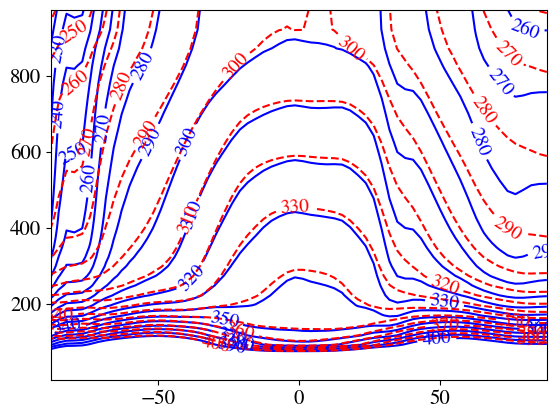

In [47]:
cs = plt.contour(lat,pfull,np.mean(np.mean(p1,axis = 3),axis = 0),np.linspace(0,400,41),colors = "blue")
plt.clabel(cs, inline=True, fontsize=14)

cs = plt.contour(lat,pfull,np.mean(np.mean(p2,axis = 3),axis = 0),np.linspace(0,400,41),colors = "red",linestyles = "dashed")
plt.clabel(cs, inline=True, fontsize=14)


array([[19484.19  , 20289.88  , 20774.71  , ..., 27197.87  , 27291.346 ,
        27339.127 ],
       [15825.933 , 16631.227 , 17091.465 , ..., 20525.398 , 20659.764 ,
        20736.629 ],
       [14281.188 , 14923.996 , 15266.816 , ..., 17183.898 , 17245.674 ,
        17279.502 ],
       ...,
       [ 1592.7795,  1660.5026,  1701.5552, ...,  1899.08  ,  1899.6877,
         1899.9095],
       [ 1561.0028,  1636.1816,  1679.9945, ...,  1873.5773,  1873.0094,
         1873.9584],
       [ 1521.92  ,  1604.5708,  1653.3292, ...,  1854.4695,  1852.6285,
         1852.1973]], dtype=float32)

In [ ]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")
import cartopy.crs as ccrs
import diagnostic_plot_helper as dps  
path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"
path_folder = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
delta_sst = 0
base_folder_name = "RT42_sst_"
exp_folder_name = f"{base_folder_name}{'m' + str(abs(delta_sst)) if delta_sst < 0 else str(delta_sst)}"
exp_folder_name = "RT42_sst_0_"
path = f"{path_folder}/{exp_folder_name}"
ds_age = xr.open_dataset(f"{path}/age.nc")

In [ ]:
q = ds_age.sphum.values # kg/kg
area = dps.get_area(ds_age)
phalf = 100*ds_age.phalf.values
ps = ds_age.ps.mean(dim = "time").values
g = 9.81 # m/s^2
col_air = ps/g # kg/m^2
P = ds_age.precipitation.values/col_air
W = dps.vertical_rhow_avg(q, phalf) # (time,lat,lon)

dep = np.mean(W,axis = 0)/np.mean(P, axis = 0)

lat = ds_age.lat.values
lon = ds_age.lon.values
land_mask_name = "era_land_t42.nc"
land_bool = True
if land_bool:
    lm_path = "~/Isca/exp/test_cases/realistic_continents/input/"+land_mask_name
    ds_landmask = xr.open_dataset(lm_path) 
    land_mask = ds_landmask.land_mask.values

In [ ]:
def decomp_term_time_2D_vert(term,area,phalf):
    # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_rhow_avg(term, phalf) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    
    prime = term - time_vert_2D_avg
    return term,time_vert_2D_avg,prime

def decomp_term_time_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    
    prime = term - time_2D_avg
    return term,time_2D_avg,prime
    

def decomp_term_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=False) # (time)    
    prime = term - twoD_avg
    return term,twoD_avg,prime

In [ ]:
# Source term
source = (ds_age.dt_qg_convection + ds_age.dt_qg_condensation + ds_age.dt_qg_diffusion).values # kg/kg/s # (time,pfull,lat,lon)
source, global_source, source_prime = decomp_term_time_2D_vert(source,area,phalf)

# Sink term
sink = ds_age.dt_sink.values # (time,pfull,lat,lon)
sink, global_sink, sink_prime = decomp_term_time_2D_vert(sink,area,phalf)
vert_sink = dps.vertical_rhow_avg(sink,phalf) # (time,lat,lon)

# Precipitation
P = ds_age.precipitation.values/col_air  # kg/m/m/s / kg/m^2 = kg/kg/s # (time,lat,lon)
Pstar = -vert_sink - P
P, global_P, P_prime = decomp_term_time_2D(P,area)
Pstar, global_Pstar, Pstar_prime = decomp_term_time_2D(Pstar,area)

# Lambda = qT
qT = ds_age.sphum_age_1.values # s kg/kg
qT, global_qT, qT_prime = decomp_term_time_2D_vert(qT,area,phalf)

# q
q = ds_age.sphum.values # kg/kg
q, global_q, q_prime = decomp_term_time_2D_vert(q,area,phalf)

# W
W = dps.vertical_rhow_avg(q, phalf) # (time,lat,lon)
W, global_W, W_prime = decomp_term_time_2D(W,area)

# depletion
dep = np.mean(W,axis = 0)/np.mean(P, axis = 0)
dep, global_dep, dep_prime = decomp_term_2D(dep,area)

In [ ]:
vert_source = dps.vertical_rhow_avg(source, phalf) # (time,lat,lon)
vert_source_prime = dps.vertical_rhow_avg(source_prime, phalf) # (time,lat,lon)
vert_qT = dps.vertical_rhow_avg(qT, phalf) # (time,lat,lon)
vert_qT_prime = dps.vertical_rhow_avg(qT_prime, phalf) # (time,lat,lon)


In [ ]:
cb = plt.contourf(lon,lat,np.mean(vert_qT_prime,axis = 0)/(global_W*24*60**2),levels = 25)
plt.colorbar(cb)

In [ ]:


fig, ax = plt.subplots(nrows=1, ncols=1, 
                            subplot_kw={'projection': ccrs.Robinson()},figsize = (12,5.5))

ax_age_vert = ax
dps.plot_2d(dep/(24*60**2),lat,lon,ax_age_vert,"gist_ncar",level_space=np.linspace(0,14,29),land_bool=True,land_mask=land_mask,proj = ccrs.PlateCarree())
#ax_age_vert.set_title("Control Experiment",fontsize = 25,pad = 10)

# Add gridlines
gl = ax_age_vert.gridlines(draw_labels=True, linestyle='--', color='gray')
gl.top_labels = False
gl.right_labels = False

fig.suptitle("Depletion Time[Days]",fontsize = 35)
plt.savefig(f"{path_cur}/depletion_time.png",dpi = 250,bbox_inches = "tight")

In [ ]:
path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"
path_folder = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
delta_sst = 0
base_folder_name = "RT42_sst_"
exp_folder_name = f"{base_folder_name}{'m' + str(abs(delta_sst)) if delta_sst < 0 else str(delta_sst)}"
exp_folder_name = "RT42_sst_0_"
path = f"{path_folder}/{exp_folder_name}"
ds_dyn = xr.open_dataset(f"{path}/dynamics.nc")
ds_mix = xr.open_dataset(f"{path}/mixed_layer.nc")

In [ ]:
temp = ds_dyn.temp.mean(dim = "time").values
phalf = (ds_dyn.phalf.values) # Pa
lat = ds_dyn.lat.values # Pa
ts = ds_mix.t_surf.mean(dim = "time")
lapse_rate = 0.0065 #[K/m]
g=9.81
R = 287 #m
pfull = (ds_dyn.pfull.values)

In [ ]:
def get_lapse_rate(pfull,phalf,temp):
    g=9.81
    R = 287 # Si units
    dP = phalf[1:] - phalf[:-1]
    dz = - (1/(g*pfull[:, np.newaxis, np.newaxis])) * R * temp* dP[:, np.newaxis, np.newaxis] #m
    dT = temp[1:,:,:] - temp[0:-1,:,:]
    atm_lapse_rate = -dT/dz[:-1] * 1000 # K/km
    atm_l_zonal = np.mean(atm_lapse_rate,axis = 2)
    return atm_l_zonal

def get_trop_p(col_lr_f,P_f):
    #plt.plot(col, P_f[1:]/100,marker = ".")
    #plt.ylim(1000,-10)
    #plt.vlines(2,0,1000,color = "red")
    mask = col_lr_f < 2
    #print(mask)
    i = 0
    for val in mask:
        if val:
            cur_P = P_f[i]/100
            #print(i,cur_P)
            if cur_P < 700:
                #print(i)
                return (cur_P + P_f[i-1]/100)/2
            else: continue
            
        i +=1

def tropopause_height(pfull,phalf,temp,lat):
    phalf *= 100
    pfull *= 100
    atm_l_zonal = get_lapse_rate(pfull,phalf,temp)
    trop_p = np.zeros_like(lat)
    P_f = np.flip(pfull)
    for i in range(len(lat)):
        col_lr = atm_l_zonal[:,i]
        col_lr_f = np.flip(col_lr)
        val_P = get_trop_p(col_lr_f,P_f)
        trop_p[i] = val_P
    return trop_p

In [ ]:
tropopause_h = tropopause_height(pfull,phalf,temp,lat)

In [ ]:
tropopause_h

In [ ]:
plt.plot(lat,tropopause_h)
plt.ylim(1000,0)

In [ ]:
plt.plot(col_lr_f, P_f/100,marker = ".")
plt.vlines(2,0,1000,color = "red")
plt.hlines(trop_p,-2,8,color = "red")
plt.ylim(1000,-20)

In [ ]:
trop = np.zeros_like(lat)
i =0
for ind in idxs:
    trop[i] = P[ind+1]
    i+=1

In [ ]:
plt.plot(lat,trop_p)

In [ ]:
cb = plt.contourf(lat,pfull[1:-1]/100,atm_l_zonal,levels =np.linspace(0,4,101) ,cmap = "seismic")
plt.colorbar(cb)
plt.ylim(975,0)